# 003a -- Market Regime Classification

**Author:** Wayne Kirk Schmidt  
**Email:** wayne.kirk.schmidt@gmail.com

## Purpose

`003a_regime_classification.ipynb` extends the base analysis in `003_analysis.ipynb`
with a formal framework for identifying, classifying, and characterizing **market regimes**
in the cryptocurrency universe.

The central insight motivating this notebook:

> **A signal that works in one regime may actively fail in another.**  
> Finding a pattern is necessary but not sufficient -- it must be regime-aware to be tradeable.

## Framework

The analysis proceeds in six stages:

1. **Segmentation** -- identify macro regime boundaries using rolling BTC return
2. **Classification** -- label each segment (Bull / Bear / Transition / Dragon)
3. **Theme Extraction** -- identify repeating shock patterns within each regime
4. **ADSR Characterization** -- measure Attack, Decay, Sustain, Release of each shock type
5. **Correlation Mapping** -- identify which coins move together within each regime
6. **Tradability Filter** -- separate context (interesting but not actionable) from signal (tradeable)

## The Tradability Principle

> *"I might find signal, but if I can't trade it reliably, then all it is is context --  
> useful, but I won't bet on it."*

A finding passes the tradability filter only if it satisfies ALL of:
- Statistically significant (win rate, mean return, t-test)
- ADSR window is executable (entry and exit are defined and observable)
- Expected return exceeds friction (transaction costs + slippage)
- Consistent across regime instances (not driven by one outlier event)

## Outputs

Written to `output/003a_regimes/`:

| File | Description |
|------|-------------|
| `regime_series.pkl` | Daily regime classification for every date |
| `regime_manifest.pkl` | Regime boundaries, labels, and metadata |
| `adsr_profiles.pkl` | ADSR characterization per shock type per regime |
| `regime_correlations.pkl` | Cross-asset correlation matrices per regime |
| `tradable_signals.pkl` | Signals that passed the tradability filter |
| `context_signals.pkl` | Signals found but not tradeable -- documented |
| `dragons.pkl` | Dragon events -- major shocks excluded from strategy |

## Pipeline Position

```
001_download  -> data acquisition
002_enrich    -> feature engineering
003_analysis  -> shock detection
003a_regimes  <- you are here
     -
004_strategy  -> regime-gated signal construction
     -
005_backtest  -> execution and performance evaluation
```


### 1. Imports and Environment Setup

Standard imports plus scipy for statistical testing.


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
from datetime import datetime, UTC


### 2. Environment Configuration

Key parameters for regime classification:

- `REGIME_WINDOW` -- rolling window (days) for BTC return used to classify regime
- `BULL_THRESHOLD` -- BTC rolling return above this = Bull regime
- `BEAR_THRESHOLD` -- BTC rolling return below this = Bear regime
- `DRAGON_SIGMA` -- all-coin shock at this level = Dragon event
- `SIGNAL_SIGMA` -- minimum z-score magnitude to qualify as a shock event


In [2]:
# Paths
BASE_DIR    = Path('../output')
ENRICH_DIR  = BASE_DIR / '002_enrich'
ANALYSIS_DIR= BASE_DIR / '003_analysis'
OUTPUT_DIR  = BASE_DIR / '003a_regimes'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_FILE = BASE_DIR / 'manifest.pkl'

# Universe
UNIVERSE = [
    'BTCUSDT','ETHUSDT','BNBUSDT','SOLUSDT','XRPUSDT',
    'ADAUSDT','DOGEUSDT','AVAXUSDT','LTCUSDT'
]

TIER1 = ['BTCUSDT', 'ETHUSDT', 'XRPUSDT']
TIER2 = ['BNBUSDT', 'SOLUSDT', 'ADAUSDT']
TIER3 = ['DOGEUSDT', 'AVAXUSDT', 'LTCUSDT']

def coin_name(c): return c.replace('USDT','')

# Regime classifier parameters
REGIME_WINDOW    = 60    # rolling days for BTC return
BULL_THRESHOLD   =  0.10 # BTC 60d return > +10% -> Bull
BEAR_THRESHOLD   = -0.15 # BTC 60d return < -15% -> Bear
DRAGON_MIN_COINS =  8    # ≥8 coins shocked simultaneously -> Dragon
DRAGON_SIGMA     =  2.5  # sigma threshold for dragon detection
SIGNAL_SIGMA     =  2.0  # minimum sigma for any shock event

# ADSR measurement windows
ATTACK_WINDOW    =  2    # days to measure attack sharpness
SUSTAIN_CHECK    =  [3, 6]  # days to confirm sustain phase
RELEASE_WINDOW   = 40    # max days to measure release

print("Configuration loaded.")
print(f"  Regime window:    {REGIME_WINDOW} days")
print(f"  Bull threshold:   >{BULL_THRESHOLD:+.0%}")
print(f"  Bear threshold:   <{BEAR_THRESHOLD:+.0%}")
print(f"  Dragon: ≥{DRAGON_MIN_COINS} coins at {DRAGON_SIGMA}σ+")
print(f"  Signal sigma:     ≥{SIGNAL_SIGMA}σ")


Configuration loaded.
  Regime window:    60 days
  Bull threshold:   >+10%
  Bear threshold:   <-15%
  Dragon: ≥8 coins at 2.5σ+
  Signal sigma:     ≥2.0σ


### 3. Load Prior Stage Artifacts

Loads enriched datasets from Stage 2 and shock events from Stage 3.


In [3]:
# Load manifest
manifest = pd.read_pickle(MANIFEST_FILE) if MANIFEST_FILE.exists() else {}
manifest.setdefault('003a_regimes', {})

# Load Stage 2 artifacts
z_scores     = pd.read_pickle(ENRICH_DIR / 'z_scores.pkl')
returns_full = pd.read_pickle(ENRICH_DIR / 'returns_full.pkl')
price_wide   = pd.read_pickle(ENRICH_DIR / 'price_wide.pkl')
rolling_sigma= pd.read_pickle(ENRICH_DIR / 'rolling_sigma.pkl')

# Normalize index to UTC
for df in [z_scores, returns_full, price_wide, rolling_sigma]:
    df.index = pd.to_datetime(df.index, utc=True)

print(f"z_scores:      {z_scores.shape}")
print(f"returns_full:  {returns_full.shape}")
print(f"price_wide:    {price_wide.shape}")
print(f"Date range:    {z_scores.index[0].date()} -> {z_scores.index[-1].date()}")
print(f"Trading days:  {len(z_scores)}")


z_scores:      (1028, 9)
returns_full:  (1047, 9)
price_wide:    (1242, 9)
Date range:    2023-08-03 -> 2026-05-26
Trading days:  1028


### 4. Regime Classification

Classifies every trading day into one of four regimes using rolling 60-day BTC return:

| Regime | Condition | Interpretation |
|--------|-----------|----------------|
| `BULL` | BTC 60d return > +10% | Strong uptrend -- risk-on |
| `BEAR` | BTC 60d return < -15% | Sustained downtrend -- risk-off |
| `TRANSITION` | Between thresholds | Unclear direction -- stand aside |
| `DRAGON` | ≥8 coins shock simultaneously | Major market event -- own category |

Dragon events are identified separately and override the rolling regime label.


In [4]:
# Step 1: Rolling BTC return classifier
btc_60d = price_wide['BTCUSDT'].pct_change(REGIME_WINDOW)

def classify_regime(btc_ret):
    if pd.isna(btc_ret):
        return 'UNKNOWN'
    elif btc_ret > BULL_THRESHOLD:
        return 'BULL'
    elif btc_ret < BEAR_THRESHOLD:
        return 'BEAR'
    else:
        return 'TRANSITION'

regime_series = btc_60d.apply(classify_regime).rename('regime')

# Step 2: Identify Dragon events -- override regime label
dragon_dates = set()
for date in z_scores.index:
    n_shocked = (abs(z_scores.loc[date]) >= DRAGON_SIGMA).sum()
    if n_shocked >= DRAGON_MIN_COINS:
        dragon_dates.add(date)
        regime_series.loc[date] = 'DRAGON'

print(f"Regime distribution:")
for regime, count in regime_series.value_counts().items():
    pct = count / len(regime_series) * 100
    bar = '|' * int(pct / 2)
    print(f"  {regime:<12}: {count:>4} days ({pct:>5.1f}%)  {bar}")

print(f"\nDragon events: {len(dragon_dates)}")
for d in sorted(dragon_dates):
    n = int((abs(z_scores.loc[d]) >= DRAGON_SIGMA).sum())
    print(f"  {d.date()}  {n} coins shocked at ≥{DRAGON_SIGMA}σ")


Regime distribution:
  TRANSITION  :  539 days ( 43.4%)  |||||||||||||||||||||
  BULL        :  491 days ( 39.5%)  |||||||||||||||||||
  BEAR        :  147 days ( 11.8%)  |||||
  UNKNOWN     :   60 days (  4.8%)  ||
  DRAGON      :    5 days (  0.4%)  

Dragon events: 5
  2023-08-17  8 coins shocked at ≥2.5σ
  2025-05-08  8 coins shocked at ≥2.5σ
  2025-10-10  8 coins shocked at ≥2.5σ
  2025-11-03  8 coins shocked at ≥2.5σ
  2026-02-05  9 coins shocked at ≥2.5σ


### 5. Regime Timeline

Visualizes the full regime classification across the dataset period.


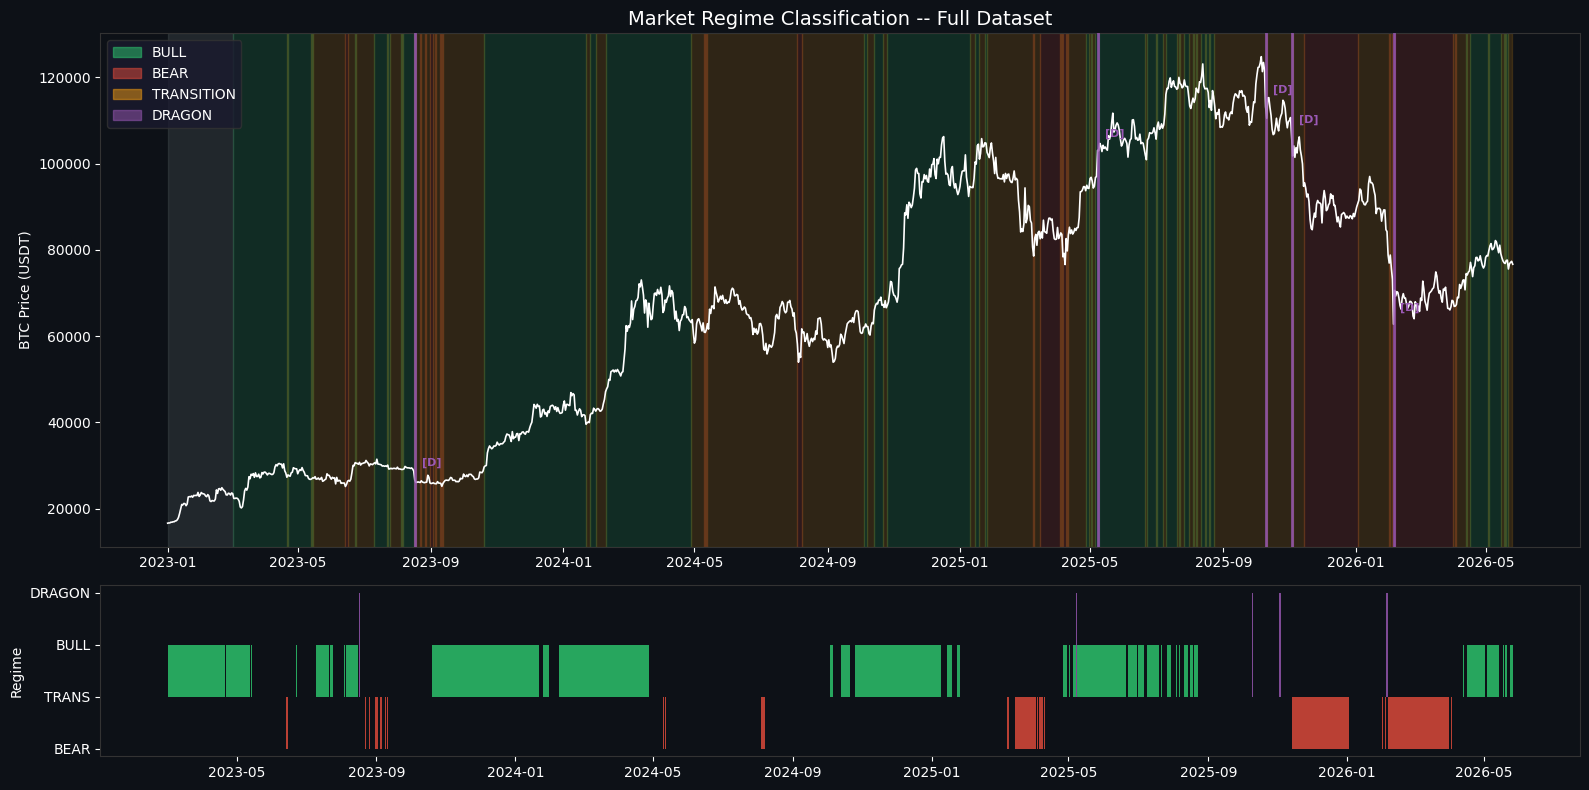

Regime timeline saved.


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

# BTC price with regime coloring
ax1 = axes[0]
btc_price = price_wide['BTCUSDT']

colors = {
    'BULL': '#2ecc71', 'BEAR': '#e74c3c',
    'TRANSITION': '#f39c12', 'DRAGON': '#9b59b6', 'UNKNOWN': '#95a5a6'
}

# Plot BTC price
ax1.plot(btc_price.index, btc_price.values, color='white', linewidth=1.2, zorder=3)

# Shade background by regime
prev_regime = None
start_date  = None
for date, regime in regime_series.items():
    if regime != prev_regime:
        if prev_regime is not None and prev_regime in colors:
            ax1.axvspan(start_date, date, alpha=0.15,
                       color=colors[prev_regime], zorder=1)
        start_date  = date
        prev_regime = regime

# Mark dragon events
for d in sorted(dragon_dates):
    ax1.axvline(d, color='#9b59b6', linewidth=2, alpha=0.8, zorder=4)
    ax1.annotate('[D]', xy=(d, btc_price.loc[d]),
                xytext=(5, 10), textcoords='offset points', fontsize=8,
                color='#9b59b6', fontweight='bold')

ax1.set_facecolor('#0d1117')
ax1.set_ylabel('BTC Price (USDT)', color='white')
ax1.tick_params(colors='white')
ax1.set_title('Market Regime Classification -- Full Dataset', color='white', fontsize=14)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

legend_patches = [mpatches.Patch(color=colors[r], alpha=0.5, label=r)
                  for r in ['BULL','BEAR','TRANSITION','DRAGON']]
ax1.legend(handles=legend_patches, loc='upper left',
          facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

# Regime bar chart
ax2 = axes[1]
regime_numeric = regime_series.map(
    {'BULL': 1, 'BEAR': -1, 'TRANSITION': 0, 'DRAGON': 2, 'UNKNOWN': 0}
)
for regime, val in [('BULL',1),('BEAR',-1),('TRANSITION',0),('DRAGON',2)]:
    mask = regime_series == regime
    ax2.bar(regime_series.index[mask], [val]*mask.sum(),
           color=colors[regime], alpha=0.8, width=1)

ax2.set_facecolor('#0d1117')
ax2.set_ylabel('Regime', color='white')
ax2.tick_params(colors='white')
ax2.set_yticks([-1, 0, 1, 2])
ax2.set_yticklabels(['BEAR', 'TRANS', 'BULL', 'DRAGON'], color='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'regime_timeline.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Regime timeline saved.")


### 6. Regime Transition Table

Documents every regime change with BTC return context.


In [6]:
print("Regime Transition Log:")
print(f"{'Date':<14} {'From':<14} {'To':<14} {'BTC 60d':>10}  Notes")
print("-" * 65)

prev = None
transitions = []
for date, regime in regime_series.items():
    if regime != prev:
        btc_ret = btc_60d.loc[date] if date in btc_60d.index else np.nan
        note = '[DRAGON] DRAGON' if regime == 'DRAGON' else ''
        if prev is not None:
            print(f"{str(date.date()):<14} {str(prev):<14} {regime:<14} "
                  f"{btc_ret:>+10.1%}  {note}")
            transitions.append({
                'date': date, 'from': prev, 'to': regime, 'btc_60d': btc_ret
            })
        prev = regime

transition_df = pd.DataFrame(transitions)
print(f"\nTotal transitions: {len(transition_df)}")


Regime Transition Log:
Date           From           To                BTC 60d  Notes
-----------------------------------------------------------------
2023-03-02     UNKNOWN        BULL               +41.2%  
2023-04-21     BULL           TRANSITION          +9.8%  
2023-04-22     TRANSITION     BULL               +13.8%  
2023-05-13     BULL           TRANSITION          +8.5%  
2023-05-14     TRANSITION     BULL               +10.9%  
2023-05-15     BULL           TRANSITION          +8.6%  
2023-06-14     TRANSITION     BEAR               -17.1%  
2023-06-16     BEAR           TRANSITION         -10.4%  
2023-06-23     TRANSITION     BULL               +11.4%  
2023-06-24     BULL           TRANSITION          +7.9%  
2023-07-10     TRANSITION     BULL               +12.8%  
2023-07-22     BULL           TRANSITION          +9.4%  
2023-07-23     TRANSITION     BULL               +14.2%  
2023-07-25     BULL           TRANSITION          +9.4%  
2023-08-04     TRANSITION     BULL  

### 7. Shock Theme Extraction by Regime

For each regime, identifies the dominant shock patterns:
- How many coins are typically shocked together?
- What direction (positive / negative / mixed)?
- What sigma magnitude?


In [7]:
print("Shock Theme Analysis by Regime")
print("=" * 65)

theme_results = {}

for regime in ['BULL', 'BEAR', 'TRANSITION']:
    regime_dates = set(regime_series[regime_series == regime].index)
    
    shock_events = []
    for date in z_scores.index:
        if date not in regime_dates:
            continue
        n_neg = (z_scores.loc[date] <= -SIGNAL_SIGMA).sum()
        n_pos = (z_scores.loc[date] >=  SIGNAL_SIGMA).sum()
        n_total = n_neg + n_pos
        if n_total == 0:
            continue
        max_abs_z = abs(z_scores.loc[date]).max()
        direction = 'NEG' if n_neg > n_pos else 'POS' if n_pos > n_neg else 'MIXED'
        shock_events.append({
            'date': date,
            'n_neg': n_neg,
            'n_pos': n_pos,
            'n_total': n_total,
            'max_z': max_abs_z,
            'direction': direction
        })
    
    theme_results[regime] = shock_events
    
    print(f"\n{regime} regime ({len(regime_dates)} days, {len(shock_events)} shock days)")
    print(f"  Shock frequency: {len(shock_events)/len(regime_dates)*100:.1f}% of days")
    
    if shock_events:
        df = pd.DataFrame(shock_events)
        print(f"  Coins shocked per event:")
        print(f"    Mean: {df['n_total'].mean():.1f}  "
              f"Median: {df['n_total'].median():.0f}  "
              f"Max: {df['n_total'].max():.0f}")
        print(f"  Direction breakdown:")
        for d, count in df['direction'].value_counts().items():
            print(f"    {d}: {count} ({count/len(df)*100:.0f}%)")
        print(f"  Sigma distribution:")
        for thresh in [2.0, 2.5, 3.0, 3.5]:
            n = (df['max_z'] >= thresh).sum()
            print(f"    ≥{thresh}σ: {n} events ({n/len(df)*100:.0f}%)")


Shock Theme Analysis by Regime

BULL regime (491 days, 124 shock days)
  Shock frequency: 25.3% of days
  Coins shocked per event:
    Mean: 2.1  Median: 1  Max: 9
  Direction breakdown:
    POS: 102 (82%)
    NEG: 22 (18%)
  Sigma distribution:
    ≥2.0σ: 124 events (100%)
    ≥2.5σ: 70 events (56%)
    ≥3.0σ: 36 events (29%)
    ≥3.5σ: 10 events (8%)

BEAR regime (147 days, 19 shock days)
  Shock frequency: 12.9% of days
  Coins shocked per event:
    Mean: 3.0  Median: 2  Max: 9
  Direction breakdown:
    POS: 11 (58%)
    NEG: 8 (42%)
  Sigma distribution:
    ≥2.0σ: 19 events (100%)
    ≥2.5σ: 10 events (53%)
    ≥3.0σ: 3 events (16%)
    ≥3.5σ: 1 events (5%)

TRANSITION regime (539 days, 85 shock days)
  Shock frequency: 15.8% of days
  Coins shocked per event:
    Mean: 2.6  Median: 2  Max: 9
  Direction breakdown:
    POS: 50 (59%)
    NEG: 35 (41%)
  Sigma distribution:
    ≥2.0σ: 85 events (100%)
    ≥2.5σ: 42 events (49%)
    ≥3.0σ: 14 events (16%)
    ≥3.5σ: 4 events (5%)


### 8. ADSR Characterization

For each shock type within each regime, measures the four phases of the price response:

- **Attack** -- speed and magnitude of the initial move (day 0 to t+2)
- **Decay** -- continuation of the move after the shock (t+2 to t+6)  
- **Sustain** -- persistence of displacement from pre-shock level (t+3 to t+10)
- **Release** -- recovery toward pre-shock level (t+6 onward)

The ADSR profile determines whether a shock is tradeable and when to enter/exit.


In [8]:
print("ADSR Profile Analysis")
print("=" * 65)

adsr_profiles = {}

# Analyze single-coin shocks by tier and regime
for regime in ['BULL', 'BEAR']:
    regime_dates = set(regime_series[regime_series == regime].index)
    adsr_profiles[regime] = {}
    
    print(f"\n{'='*55}")
    print(f"REGIME: {regime}")
    print(f"{'='*55}")
    
    for tier_label, tier_coins in [
        ('Tier1', TIER1), ('Tier2', TIER2), ('Tier3', TIER3)
    ]:
        # Single-coin negative shocks
        events = []
        for date in z_scores.index:
            if date not in regime_dates:
                continue
            neg_coins = z_scores.columns[
                z_scores.loc[date] <= -SIGNAL_SIGMA
            ].tolist()
            pos_coins = z_scores.columns[
                z_scores.loc[date] >= SIGNAL_SIGMA
            ].tolist()
            # Single negative coin shock
            if len(neg_coins) != 1 or len(pos_coins) != 0:
                continue
            coin = neg_coins[0]
            if coin not in tier_coins:
                continue
            if date not in returns_full.index:
                continue
            idx = returns_full.index.get_loc(date)
            if idx + RELEASE_WINDOW >= len(returns_full):
                continue
            fwd = returns_full.iloc[idx+1:idx+RELEASE_WINDOW+1][coin]
            cum = (1 + fwd).cumprod() - 1
            events.append({
                'date': date,
                'coin': coin,
                'z': z_scores.loc[date, coin],
                'cum': cum.values
            })
        
        if not events:
            continue
        
        arr = np.array([e['cum'] for e in events])
        
        # ADSR measurements
        attack_mag  = arr[:, 0].mean()        # t+1 mean (attack strength)
        decay_mag   = arr[:, 2].mean()        # t+3 mean (decay direction)
        sustain_mag = arr[:, 5].mean()        # t+6 mean (sustain level)
        sustain_pct = (arr[:, 5] < 0).mean() # % still negative at t+6
        
        # Release: first day mean turns positive after t+3
        release_day = None
        for t in range(3, RELEASE_WINDOW):
            if t < arr.shape[1] and arr[:, t].mean() > 0:
                release_day = t + 1
                break
        
        adsr_profiles[regime][tier_label] = {
            'n': len(events),
            'attack': attack_mag,
            'decay': decay_mag,
            'sustain': sustain_mag,
            'sustain_pct_neg': sustain_pct,
            'release_day': release_day,
        }
        
        print(f"\n  {tier_label} ({len(events)} events)")
        print(f"  Attack  (t+1 mean):     {attack_mag:>+8.2%}")
        print(f"  Decay   (t+3 mean):     {decay_mag:>+8.2%}")
        print(f"  Sustain (t+6 mean):     {sustain_mag:>+8.2%}  "
              f"({sustain_pct:.0%} still negative)")
        if release_day:
            print(f"  Release (first + mean): t+{release_day}")
        else:
            print(f"  Release:                not observed within {RELEASE_WINDOW} days [DRAGON]")
        
        # ADSR verdict
        if release_day and release_day <= 10 and sustain_pct >= 0.6:
            verdict = "TRADEABLE -- clear sustain + release window"
        elif release_day and release_day <= 40 and sustain_pct >= 0.5:
            verdict = "CANDIDATE -- release present but wide window"
        elif not release_day:
            verdict = "DRAGON TERRITORY -- no release observed"
        else:
            verdict = "CONTEXT ONLY -- insufficient sustain or release"
        print(f"  Verdict: {verdict}")

pd.to_pickle(adsr_profiles, OUTPUT_DIR / 'adsr_profiles.pkl')
print("\nADSR profiles saved.")


ADSR Profile Analysis

REGIME: BULL

  Tier1 (4 events)
  Attack  (t+1 mean):       -1.28%
  Decay   (t+3 mean):       -1.16%
  Sustain (t+6 mean):       -2.28%  (100% still negative)
  Release (first + mean): t+17
  Verdict: CANDIDATE -- release present but wide window

  Tier2 (3 events)
  Attack  (t+1 mean):       +1.22%
  Decay   (t+3 mean):       -0.56%
  Sustain (t+6 mean):       +4.75%  (0% still negative)
  Release (first + mean): t+4
  Verdict: CONTEXT ONLY -- insufficient sustain or release

  Tier3 (2 events)
  Attack  (t+1 mean):       +1.16%
  Decay   (t+3 mean):       +0.82%
  Sustain (t+6 mean):       +4.92%  (0% still negative)
  Release (first + mean): t+4
  Verdict: CONTEXT ONLY -- insufficient sustain or release

REGIME: BEAR

  Tier1 (1 events)
  Attack  (t+1 mean):       +0.82%
  Decay   (t+3 mean):       -2.61%
  Sustain (t+6 mean):       -8.10%  (100% still negative)
  Release:                not observed within 40 days [DRAGON]
  Verdict: DRAGON TERRITORY -- no 

### 9. Cross-Asset Correlation by Regime

Measures pairwise return correlations within each regime. 
Identifies which coins are most/least correlated -- revealing potential
diversification or amplification effects specific to each market state.


In [9]:
print("Cross-Asset Correlation by Regime")
print("=" * 65)

regime_correlations = {}

for regime in ['BULL', 'BEAR', 'TRANSITION']:
    regime_dates = regime_series[regime_series == regime].index
    regime_returns = returns_full.loc[
        returns_full.index.isin(regime_dates)
    ]
    
    if len(regime_returns) < 20:
        print(f"\n{regime}: insufficient data ({len(regime_returns)} days)")
        continue
    
    corr = regime_returns.corr()
    regime_correlations[regime] = corr
    
    # Summary stats
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    vals  = upper.stack().values
    
    print(f"\n{regime} regime ({len(regime_returns)} days)")
    print(f"  Mean correlation:   {vals.mean():.3f}")
    print(f"  Min correlation:    {vals.min():.3f}")
    print(f"  Max correlation:    {vals.max():.3f}")
    
    # Highest and lowest pairs
    pairs = upper.stack().sort_values(ascending=False)
    print(f"  Most correlated:    {pairs.index[0][0].replace('USDT','')} ↔ "
          f"{pairs.index[0][1].replace('USDT','')} ({pairs.iloc[0]:.3f})")
    print(f"  Least correlated:   {pairs.index[-1][0].replace('USDT','')} ↔ "
          f"{pairs.index[-1][1].replace('USDT','')} ({pairs.iloc[-1]:.3f})")
    
    # BTC correlations specifically
    btc_corrs = corr['BTCUSDT'].drop('BTCUSDT').sort_values(ascending=False)
    print(f"  BTC correlations:")
    for coin, val in btc_corrs.items():
        bar = '|' * int(val * 20)
        print(f"    {coin.replace('USDT',''):<8} {val:.3f}  {bar}")

pd.to_pickle(regime_correlations, OUTPUT_DIR / 'regime_correlations.pkl')
print("\nCorrelations saved.")


Cross-Asset Correlation by Regime

BULL regime (413 days)
  Mean correlation:   nan
  Min correlation:    nan
  Max correlation:    nan
  Most correlated:    BTC ↔ ETH (0.731)
  Least correlated:   XRP ↔ XRP (nan)
  BTC correlations:
    ETH      0.731  ||||||||||||||
    DOGE     0.708  ||||||||||||||
    SOL      0.633  ||||||||||||
    ADA      0.620  ||||||||||||
    AVAX     0.591  |||||||||||
    BNB      0.525  ||||||||||
    LTC      0.491  |||||||||
    XRP      0.464  |||||||||

BEAR regime (145 days)
  Mean correlation:   nan
  Min correlation:    nan
  Max correlation:    nan
  Most correlated:    BTC ↔ ETH (0.907)
  Least correlated:   XRP ↔ XRP (nan)
  BTC correlations:
    ETH      0.907  ||||||||||||||||||
    SOL      0.871  |||||||||||||||||
    ADA      0.837  ||||||||||||||||
    LTC      0.827  ||||||||||||||||
    AVAX     0.824  ||||||||||||||||
    BNB      0.821  ||||||||||||||||
    DOGE     0.801  ||||||||||||||||
    XRP      0.792  |||||||||||||||

TRANSITI

### 10. Tradability Filter

Applies the full tradability filter to all candidate signals:

1. **Statistical significance** -- t-test on trade returns (p < 0.05)
2. **Win rate** -- ≥ 65%
3. **ADSR executability** -- entry and exit windows are defined
4. **Expected return > friction** -- mean return > 40 bps (round-trip cost estimate)
5. **Consistency** -- not driven by a single outlier event

Signals that pass -> `tradable_signals.pkl`  
Signals that fail -> `context_signals.pkl` (documented but not traded)


In [10]:
print("Tradability Filter")
print("=" * 65)

tradable_signals = []
context_signals  = []

FRICTION = 0.0040  # 40 bps round trip

# Pre-compute regime date sets
bull_dates         = set(regime_series[regime_series == 'BULL'].index)
bear_dates         = set(regime_series[regime_series == 'BEAR'].index)
dragon_dates_set   = set(regime_series[regime_series == 'DRAGON'].index)
bear_or_dragon     = bear_dates | dragon_dates_set
all_dates          = set(regime_series.index)

def evaluate_signal(name, description, trades, friction=FRICTION):
    """Run tradability filter on a list of trade returns."""
    if not trades:
        print(f"\n[FAIL] {name}: no qualifying trades")
        return None, "no qualifying trades"

    rets = np.array([t["ret"] for t in trades])
    n    = len(rets)
    mean = rets.mean()
    win  = (rets > 0).mean()
    t_stat, p_val = stats.ttest_1samp(rets, 0)
    mean_trimmed  = np.sort(rets)[:-1].mean() if len(rets) > 1 else mean

    passes_ttest    = p_val < 0.10
    passes_winrate  = win >= 0.60
    passes_friction = mean > friction
    passes_outlier  = mean_trimmed > 0
    all_pass = passes_ttest and passes_winrate and passes_friction

    status = "TRADEABLE [PASS]" if all_pass else "CONTEXT ONLY"
    print(f"\n{'='*55}")
    print(f"  {status}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  n={n}  mean={mean:>+.2%}  win={win:.0%}  "
          f"t={t_stat:.2f}  p={p_val:.3f}")
    print(f"  Mean ex-best: {mean_trimmed:>+.2%}")
    print(f"  Filters:")
    print(f"    t-test (p<0.10):   {'[PASS]' if passes_ttest else '[FAIL]'}  "
          f"(p={p_val:.3f})")
    print(f"    Win rate (>=60%):  {'[PASS]' if passes_winrate else '[FAIL]'}  "
          f"({win:.0%})")
    print(f"    Return > friction: {'[PASS]' if passes_friction else '[FAIL]'}  "
          f"({mean:>+.2%})")
    print(f"    Outlier robust:    {'[PASS]' if passes_outlier else '[FAIL]'}  "
          f"({mean_trimmed:>+.2%})")

    reasons = []
    if not passes_ttest:    reasons.append(f"p={p_val:.3f} > 0.10")
    if not passes_winrate:  reasons.append(f"win={win:.0%} < 60%")
    if not passes_friction: reasons.append(f"mean={mean:>+.2%} < friction")

    result = {
        "name": name, "description": description,
        "n": n, "mean": mean, "win_rate": win,
        "t_stat": t_stat, "p_value": p_val,
        "mean_ex_best": mean_trimmed, "trades": trades,
        "passed": all_pass, "reason": "; ".join(reasons)
    }
    return result, "; ".join(reasons)

def collect_trades(coins, regime_set, entry_day, exit_day):
    """Collect trade returns for given coins, regime dates, entry/exit."""
    trades = []
    for coin in coins:
        shock_dates = z_scores.index[z_scores[coin] <= -SIGNAL_SIGMA]
        for date in shock_dates:
            if date not in regime_set:
                continue
            if date not in returns_full.index:
                continue
            idx = returns_full.index.get_loc(date)
            needed = exit_day + 2
            if idx + needed >= len(returns_full):
                continue
            fwd = returns_full.iloc[idx+1:idx+needed+1][coin]
            cum = (1 + fwd).cumprod() - 1
            if exit_day >= len(cum):
                continue
            entry_val = cum.values[entry_day] if entry_day > 0 else 0.0
            exit_val  = cum.values[exit_day]
            ret = ((1 + exit_val) / (1 + entry_val)) - 1 - FRICTION
            trades.append({"date": date, "coin": coin, "ret": ret})
    return trades

def collect_panic_trades(min_coins, entry_day, exit_day):
    """Collect all-coin panic recovery trades."""
    trades = []
    for date in z_scores.index:
        n_neg = (z_scores.loc[date] <= -SIGNAL_SIGMA).sum()
        if n_neg < min_coins:
            continue
        shocked = z_scores.columns[
            z_scores.loc[date] <= -SIGNAL_SIGMA
        ].tolist()
        for coin in shocked:
            if date not in returns_full.index:
                continue
            idx = returns_full.index.get_loc(date)
            needed = exit_day + 2
            if idx + needed >= len(returns_full):
                continue
            fwd = returns_full.iloc[idx+1:idx+needed+1][coin]
            cum = (1 + fwd).cumprod() - 1
            if exit_day >= len(cum):
                continue
            entry_val = cum.values[entry_day] if entry_day > 0 else 0.0
            exit_val  = cum.values[exit_day]
            ret = ((1 + exit_val) / (1 + entry_val)) - 1 - FRICTION
            trades.append({"date": date, "coin": coin, "ret": ret})
    return trades

# ── Signal 1: Tier 1 single-coin shock -- BULL regime ────────────
def collect_tier1_bull(entry_day, exit_day):
    trades = []
    neg_single = (
        (z_scores <= -SIGNAL_SIGMA).sum(axis=1) == 1
    ) & (
        (z_scores >= SIGNAL_SIGMA).sum(axis=1) == 0
    )
    for date in z_scores.index[neg_single]:
        if date not in bull_dates:
            continue
        coin = z_scores.columns[(z_scores.loc[date] <= -SIGNAL_SIGMA)][0]
        if coin not in TIER1:
            continue
        if date not in returns_full.index:
            continue
        idx = returns_full.index.get_loc(date)
        if idx + exit_day + 2 >= len(returns_full):
            continue
        fwd = returns_full.iloc[idx+1:idx+exit_day+2][coin]
        cum = (1 + fwd).cumprod() - 1
        # persistence filters
        if len(cum) > 2 and cum.values[2] >= 0:
            continue
        if len(cum) > 5 and cum.values[5] >= 0:
            continue
        if exit_day >= len(cum):
            continue
        entry_val = cum.values[entry_day] if entry_day > 0 else 0.0
        exit_val  = cum.values[exit_day]
        ret = ((1 + exit_val) / (1 + entry_val)) - 1 - FRICTION
        trades.append({"date": date, "coin": coin, "ret": ret})
    return trades

t1_trades = collect_tier1_bull(entry_day=5, exit_day=38)
r, reason = evaluate_signal(
    "Tier1 single-coin shock -- BULL regime (buy t+6, sell t+39)",
    "BTC/ETH/XRP single negative shock, persistent faller, BULL regime",
    t1_trades
)
if r:
    (tradable_signals if r["passed"] else context_signals).append(r)
else:
    context_signals.append({"name": "Tier1 BULL", "reason": reason})

# ── Signal 2: ADA/XRP shock -- BEAR or DRAGON ────────────────────
for hold_label, exit_day in [("t+5", 4), ("t+10", 9)]:
    trades = collect_trades(
        coins=['ADAUSDT', 'XRPUSDT'],
        regime_set=bear_or_dragon,
        entry_day=0,
        exit_day=exit_day
    )
    r, reason = evaluate_signal(
        f"ADA/XRP shock -- BEAR or DRAGON regime, buy t+1, sell {hold_label}",
        f"ADA or XRP negative shock (>=2sigma) in BEAR or DRAGON regime",
        trades
    )
    if r:
        (tradable_signals if r["passed"] else context_signals).append(r)
    else:
        context_signals.append({
            "name": f"ADA/XRP BEAR/DRAGON {hold_label}",
            "reason": reason
        })

# ── Signal 3: All-coin panic recovery ────────────────────────────
panic_trades = collect_panic_trades(min_coins=8, entry_day=0, exit_day=4)
r, reason = evaluate_signal(
    "All-coin panic recovery -- any regime",
    ">=8 coins shocked simultaneously, buy t+1, sell t+5",
    panic_trades
)
if r:
    (tradable_signals if r["passed"] else context_signals).append(r)
else:
    context_signals.append({"name": "Panic recovery", "reason": reason})

# ── Summary ───────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"SUMMARY")
print(f"{'='*55}")
print(f"  Tradeable signals: {len(tradable_signals)}")
print(f"  Context signals:   {len(context_signals)}")
for s in tradable_signals:
    print(f"  [PASS] {s['name']}")
for s in context_signals:
    print(f"  [FAIL] {s['name']}  ({s.get('reason','')})")


Tradability Filter

  CONTEXT ONLY
  Tier1 single-coin shock -- BULL regime (buy t+6, sell t+39)
  n=4  mean=+12.34%  win=75%  t=1.81  p=0.168
  Mean ex-best: +7.77%
  Filters:
    t-test (p<0.10):   [FAIL]  (p=0.168)
    Win rate (>=60%):  [PASS]  (75%)
    Return > friction: [PASS]  (+12.34%)
    Outlier robust:    [PASS]  (+7.77%)

  TRADEABLE [PASS]
  ADA/XRP shock -- BEAR or DRAGON regime, buy t+1, sell t+5
  n=13  mean=+5.17%  win=92%  t=4.20  p=0.001
  Mean ex-best: +4.35%
  Filters:
    t-test (p<0.10):   [PASS]  (p=0.001)
    Win rate (>=60%):  [PASS]  (92%)
    Return > friction: [PASS]  (+5.17%)
    Outlier robust:    [PASS]  (+4.35%)

  TRADEABLE [PASS]
  ADA/XRP shock -- BEAR or DRAGON regime, buy t+1, sell t+10
  n=13  mean=+6.13%  win=92%  t=3.42  p=0.005
  Mean ex-best: +4.87%
  Filters:
    t-test (p<0.10):   [PASS]  (p=0.005)
    Win rate (>=60%):  [PASS]  (92%)
    Return > friction: [PASS]  (+6.13%)
    Outlier robust:    [PASS]  (+4.87%)

  TRADEABLE [PASS]
  All-c

### 11. Dragon Documentation

Documents all Dragon events -- major simultaneous multi-coin shocks that are
classified separately from the regime-based strategy framework.

> **"Here be dragons"** -- these events are acknowledged, characterized,
> and explicitly excluded from systematic trading strategies.
> They may be traded opportunistically but not systematically.


In [11]:
print("[DRAGON] DRAGON EVENT DOCUMENTATION")
print("=" * 65)

dragons = []
for date in sorted(dragon_dates):
    shocked_coins = z_scores.columns[
        abs(z_scores.loc[date]) >= DRAGON_SIGMA
    ].tolist()
    n_shocked = len(shocked_coins)
    directions = {c: '+' if z_scores.loc[date,c] > 0 else '-'
                  for c in shocked_coins}
    
    # 10-day forward path for all shocked coins
    fwd_paths = {}
    if date in returns_full.index:
        idx = returns_full.index.get_loc(date)
        if idx + 10 < len(returns_full):
            for coin in shocked_coins:
                fwd = returns_full.iloc[idx+1:idx+11][coin]
                cum = (1 + fwd).cumprod() - 1
                fwd_paths[coin] = cum.values
    
    dragon = {
        'date': date,
        'n_shocked': n_shocked,
        'coins': shocked_coins,
        'directions': directions,
        'max_z': abs(z_scores.loc[date]).max(),
        'fwd_paths': fwd_paths,
    }
    dragons.append(dragon)
    
    coin_str = ' '.join([f"{coin_name(c)}{directions[c]}"
                         for c in shocked_coins])
    print(f"\n  {date.date()}  n={n_shocked}  max_z={dragon['max_z']:.2f}σ")
    print(f"  Coins: {coin_str}")
    
    if fwd_paths:
        mean_path = np.mean(list(fwd_paths.values()), axis=0)
        print(f"  Mean forward path:")
        for t in [0,1,2,4,6,9]:
            if t < len(mean_path):
                marker = "+" if mean_path[t] > 0 else "-"
                print(f"    t+{t+1}: {mean_path[t]:>+6.1%} {marker}")
    
    print(f"  Classification: HERE BE DRAGONS [DRAGON]")
    print(f"  Action: DOCUMENT ONLY -- do not trade systematically")

pd.to_pickle(dragons, OUTPUT_DIR / 'dragons.pkl')
print(f"\n{len(dragons)} dragon events documented and saved.")


[DRAGON] DRAGON EVENT DOCUMENTATION

  2023-08-17  n=8  max_z=4.16σ
  Coins: ADA- AVAX- BNB- BTC- DOGE- ETH- LTC- XRP-
  Mean forward path:
    t+1:  +0.5% +
    t+2:  +1.3% +
    t+3:  +2.3% +
    t+5:  -0.7% -
    t+7:  +0.4% +
    t+10:  +0.5% +
  Classification: HERE BE DRAGONS [DRAGON]
  Action: DOCUMENT ONLY -- do not trade systematically

  2025-05-08  n=8  max_z=4.00σ
  Coins: ADA+ AVAX+ BNB+ BTC+ DOGE+ ETH+ SOL+ XRP+
  Mean forward path:
    t+1:  +3.5% +
    t+2: +11.5% +
    t+3:  +7.4% +
    t+5: +12.2% +
    t+7:  +5.1% +
    t+10:  +6.4% +
  Classification: HERE BE DRAGONS [DRAGON]
  Action: DOCUMENT ONLY -- do not trade systematically

  2025-10-10  n=8  max_z=3.81σ
  Coins: ADA- AVAX- BTC- DOGE- ETH- LTC- SOL- XRP-
  Mean forward path:
    t+1:  -1.9% -
    t+2:  +6.1% +
    t+3:  +9.4% +
    t+5:  +2.1% +
    t+7:  -3.7% -
    t+10:  +1.2% +
  Classification: HERE BE DRAGONS [DRAGON]
  Action: DOCUMENT ONLY -- do not trade systematically

  2025-11-03  n=8  max_z=3.11σ

### 999. Persist Artifacts and Update Manifest

Saves all outputs and records completion in the shared manifest.


In [12]:
# Save all artifacts
artifacts = {
    'regime_series':      regime_series,
    'transition_df':      transition_df,
    'theme_results':      theme_results,
    'adsr_profiles':      adsr_profiles,
    'regime_correlations':regime_correlations,
    'tradable_signals':   tradable_signals,
    'context_signals':    context_signals,
    'dragons':            dragons,
}

for name, obj in artifacts.items():
    path = OUTPUT_DIR / f'{name}.pkl'
    pd.to_pickle(obj, path)
    manifest['003a_regimes'][name] = str(path)
    print(f"  Saved: {name}.pkl")

manifest['003a_regimes']['completed_at'] = datetime.now(UTC).isoformat()
pd.to_pickle(manifest, MANIFEST_FILE)

print(f"\n[PASS] Stage 003a complete.")
print(f"  Tradeable signals found: {len(tradable_signals)}")
print(f"  Context signals:         {len(context_signals)}")
print(f"  Dragons documented:      {len(dragons)}")
print(f"  Regime timeline:         {regime_series.index[0].date()} -> {regime_series.index[-1].date()}")


  Saved: regime_series.pkl
  Saved: transition_df.pkl
  Saved: theme_results.pkl
  Saved: adsr_profiles.pkl
  Saved: regime_correlations.pkl
  Saved: tradable_signals.pkl
  Saved: context_signals.pkl
  Saved: dragons.pkl

[PASS] Stage 003a complete.
  Tradeable signals found: 3
  Context signals:         1
  Dragons documented:      5
  Regime timeline:         2023-01-01 -> 2026-05-26
